In [1]:
import sklearn, skimage, cv2
print(f"sklearn: {sklearn.__version__}")
print(f"skimage: {skimage.__version__}")
print(f"cv2:     {cv2.__version__}")
print("Environment ready.")


sklearn: 1.8.0
skimage: 0.26.0
cv2:     4.13.0
Environment ready.


In [2]:
import os
import csv
import math
import numpy as np
import cv2
from PIL import Image
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.svm import SVC
from sklearn.pipeline import Pipeline
from sklearn.model_selection import train_test_split, GridSearchCV, StratifiedKFold
from sklearn.metrics import accuracy_score, classification_report, ConfusionMatrixDisplay
from sklearn.ensemble import ExtraTreesClassifier
from skimage.feature import hog as skimage_hog
import matplotlib.pyplot as plt
import joblib
from pathlib import Path

In [3]:
# ── Paths ────────────────────────────────────────────────────────────────────
PROJECT       = Path.cwd().resolve()
REFERENCE_CSV = os.path.join(PROJECT, "reference.csv")
AUG_DIR       = os.path.join(PROJECT, "aug")
AUG_CSV       = os.path.join(PROJECT, "aug.csv")
SCENES_DIR    = os.path.join(PROJECT, "game_snapshots")
LABELS_JSON   = os.path.join(SCENES_DIR, "labels.json")

# ── Collect (path_or_array, label) pairs ─────────────────────────────────────
import json
samples = []

# 1) original crops from reference.csv
with open(REFERENCE_CSV, newline="", encoding="utf-8") as f:
    for row in csv.DictReader(f):
        image_id = row["image_id"].strip()
        card     = row["card"].strip()
        if not image_id or not card:
            continue
        tag, _, idx = image_id.rpartition("_crop_")
        img_path = os.path.join(PROJECT, tag, f"crops_{tag}", f"crop_{idx}.jpg")
        if os.path.isfile(img_path):
            samples.append((img_path, card))
        else:
            print(f"[reference] missing: {img_path}")

# 2) augmented crops from aug.csv
with open(AUG_CSV, newline="", encoding="utf-8") as f:
    for row in csv.DictReader(f):
        image_id = row["image_id"].strip()
        card     = row["card"].strip()
        if not image_id or not card:
            continue
        img_path = os.path.join(AUG_DIR, f"{image_id}.jpg")
        if os.path.isfile(img_path):
            samples.append((img_path, card))
        else:
            print(f"[aug] missing: {img_path}")

print(f"Reference + aug samples: {len(samples)}")

# 3) crops extracted from game_snapshots using bounding boxes in labels.json
scene_crops_added = 0
if os.path.isfile(LABELS_JSON):
    with open(LABELS_JSON, encoding="utf-8") as f:
        labels_meta = json.load(f)
    for entry in labels_meta:
        scene_name = entry["scene"]
        img_path   = os.path.join(SCENES_DIR, "images", f"{scene_name}.jpg")
        img_bgr    = cv2.imread(img_path)
        if img_bgr is None:
            continue
        H, W = img_bgr.shape[:2]
        for pl in entry["placements"]:
            x0, y0, x1, y1 = pl["x1"], pl["y1"], pl["x2"], pl["y2"]
            x0, y0 = max(0, x0), max(0, y0)
            x1, y1 = min(W, x1), min(H, y1)
            if x1 <= x0 or y1 <= y0:
                continue
            crop = img_bgr[y0:y1, x0:x1].copy()
            samples.append((crop, pl["label"]))
            scene_crops_added += 1
    print(f"Scene crops added: {scene_crops_added}")
else:
    print(f"[scenes] labels.json not found at {LABELS_JSON}, skipping.")

print(f"Total samples: {len(samples)}")

# ── Label encoding ────────────────────────────────────────────────────────────
paths  = [s[0] for s in samples]
labels = [s[1] for s in samples]

le      = LabelEncoder()
encoded = le.fit_transform(labels)
print(f"Full classes ({len(le.classes_)}): {list(le.classes_)}")

SPECIAL_COLOR_TOKEN = "__special__"
# Cards that have no color prefix: wild (black) and draw_4 (black).
# draw_4 contains "_" so must be listed explicitly before the generic split.
SPECIAL_CARDS = {"wild", "draw_4"}
color_labels, rank_labels = [], []
for card in labels:
    if card in SPECIAL_CARDS:
        color, rank = SPECIAL_COLOR_TOKEN, card
    elif "_" in card:
        color, rank = card.split("_", 1)   # e.g. "r_draw_2" → color=r, rank=draw_2
    else:
        color, rank = SPECIAL_COLOR_TOKEN, card
    color_labels.append(color)
    rank_labels.append(rank)

# Map (color, rank) → full label string
pair_to_full_label = {}
for c, r, full in zip(color_labels, rank_labels, labels):
    pair_to_full_label[(c, r)] = full

color_le = LabelEncoder()
rank_le  = LabelEncoder()
y_color  = color_le.fit_transform(color_labels)

y_rank   = rank_le.fit_transform(rank_labels)

print(f"Rank  classes ({len(rank_le.classes_)}):  {list(rank_le.classes_)}")
print(f"Color classes ({len(color_le.classes_)}): {list(color_le.classes_)}")

Reference + aug samples: 1126
Scene crops added: 7624
Total samples: 8750
Full classes (52): [np.str_('b_1'), np.str_('b_2'), np.str_('b_3'), np.str_('b_4'), np.str_('b_5'), np.str_('b_6'), np.str_('b_7'), np.str_('b_8'), np.str_('b_9'), np.str_('b_draw_2'), np.str_('b_reverse'), np.str_('b_skip'), np.str_('draw_4'), np.str_('g_0'), np.str_('g_1'), np.str_('g_2'), np.str_('g_3'), np.str_('g_4'), np.str_('g_5'), np.str_('g_6'), np.str_('g_7'), np.str_('g_8'), np.str_('g_9'), np.str_('g_draw_2'), np.str_('g_reverse'), np.str_('g_skip'), np.str_('r_0'), np.str_('r_1'), np.str_('r_2'), np.str_('r_3'), np.str_('r_4'), np.str_('r_5'), np.str_('r_6'), np.str_('r_7'), np.str_('r_8'), np.str_('r_9'), np.str_('r_draw_2'), np.str_('r_reverse'), np.str_('r_skip'), np.str_('wild'), np.str_('y_1'), np.str_('y_2'), np.str_('y_3'), np.str_('y_4'), np.str_('y_5'), np.str_('y_6'), np.str_('y_7'), np.str_('y_8'), np.str_('y_9'), np.str_('y_draw_2'), np.str_('y_reverse'), np.str_('y_skip')]
Rank  classes 

In [4]:
# ── Feature extraction ────────────────────────────────────────────────────────
IMG_SIZE = 128
FOURIER_COEFFS = 32

def letterbox_cv2(img_bgr, size=IMG_SIZE):
    """Resize keeping aspect ratio, pad with grey to square."""
    h, w = img_bgr.shape[:2]
    scale = size / max(h, w)
    new_w, new_h = max(1, int(w * scale)), max(1, int(h * scale))
    resized = cv2.resize(img_bgr, (new_w, new_h), interpolation=cv2.INTER_LINEAR)
    canvas = np.full((size, size, 3), 128, dtype=np.uint8)
    y0 = (size - new_h) // 2
    x0 = (size - new_w) // 2
    canvas[y0:y0 + new_h, x0:x0 + new_w] = resized
    return canvas

def extract_color_feat(img_bgr):
    """
    HSV histogram restricted to saturated pixels (ignores white card border
    and grey padding). Returns a 48-dim L1-normalised vector.
    """
    hsv = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2HSV)
    mask = (hsv[:, :, 1] > 40).astype(np.uint8) * 255
    h_hist = cv2.calcHist([hsv], [0], mask, [32], [0, 180]).flatten()
    s_hist = cv2.calcHist([hsv], [1], mask, [16], [0, 256]).flatten()
    feat = np.concatenate([h_hist, s_hist])
    return feat / (feat.sum() + 1e-6)

def extract_hog_feat(img_bgr):
    gray = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2GRAY)
    return skimage_hog(
        gray,
        orientations=9,
        pixels_per_cell=(16, 16),
        cells_per_block=(2, 2),
        block_norm='L2-Hys',
    )

def extract_fourier_feat(img_bgr, n_coeffs=FOURIER_COEFFS):
    """Fourier descriptors from the largest symbol contour (magnitude only)."""
    gray = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2GRAY)
    gray = cv2.GaussianBlur(gray, (3, 3), 0)

    # Symbol tends to be darker than card face -> inverse Otsu.
    _, bw = cv2.threshold(gray, 0, 255, cv2.THRESH_BINARY_INV + cv2.THRESH_OTSU)

    # Remove border frame influence.
    bw[:8, :] = 0
    bw[-8:, :] = 0
    bw[:, :8] = 0
    bw[:, -8:] = 0

    contours, _ = cv2.findContours(bw, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_NONE)
    if not contours:
        return np.zeros(n_coeffs, dtype=np.float32)

    cnt = max(contours, key=cv2.contourArea)
    pts = cnt[:, 0, :].astype(np.float32)
    if len(pts) < max(10, n_coeffs + 1):
        return np.zeros(n_coeffs, dtype=np.float32)

    z = pts[:, 0] + 1j * pts[:, 1]
    z = z - np.mean(z)

    F = np.fft.fft(z)
    mag = np.abs(F)[1:n_coeffs + 1]  # skip DC term
    if len(mag) < n_coeffs:
        mag = np.pad(mag, (0, n_coeffs - len(mag)))

    # Scale normalization for size invariance.
    mag = mag / (mag[0] + 1e-6)
    return mag.astype(np.float32)

def extract_rank_feat(img_bgr):
    hog_vec = extract_hog_feat(img_bgr)
    fd_vec = extract_fourier_feat(img_bgr)
    return np.concatenate([hog_vec, fd_vec])

print(f"Extracting features from {len(paths)} images ...")
color_feats, rank_feats, lb_images = [], [], []
for i, p in enumerate(paths):
    img_bgr = cv2.imread(p) if isinstance(p, str) else p
    if img_bgr is None:
        raise FileNotFoundError(f"Cannot read: {p}")
    img_lb = letterbox_cv2(img_bgr)
    lb_images.append(img_lb)
    color_feats.append(extract_color_feat(img_lb))
    rank_feats.append(extract_rank_feat(img_lb))
    if (i + 1) % 500 == 0:
        print(f"  {i + 1}/{len(paths)}")

X_color = np.array(color_feats)
X_rank = np.array(rank_feats)
print(f"Done. Color feats: {X_color.shape}, Rank feats (HOG+FD): {X_rank.shape}")

Extracting features from 8750 images ...
  500/8750
  1000/8750
  1500/8750
  2000/8750
  2500/8750
  3000/8750
  3500/8750
  4000/8750
  4500/8750
  5000/8750
  5500/8750
  6000/8750
  6500/8750
  7000/8750
  7500/8750
  8000/8750
  8500/8750
Done. Color feats: (8750, 48), Rank feats (HOG+FD): (8750, 1796)


In [5]:
# ── Train / val split (stratified on full label) ─────────────────────────────
idx_all = np.arange(len(paths))
train_idx, val_idx = train_test_split(
    idx_all, test_size=0.2, random_state=42, stratify=encoded
)

X_col_tr, X_col_va = X_color[train_idx], X_color[val_idx]
X_rank_tr, X_rank_va = X_rank[train_idx], X_rank[val_idx]
y_col_tr, y_col_va = y_color[train_idx], y_color[val_idx]
y_rnk_tr, y_rnk_va = y_rank[train_idx], y_rank[val_idx]
y_full_va = encoded[val_idx]
paths_val = [paths[i] for i in val_idx]

print(f"Train: {len(train_idx)}  |  Val: {len(val_idx)}")

# ── Rotation augmentation on training set (90°, 180°, 270°) ──────────────────
# Only applied to the COLOR classifier: HSV histograms are rotation-invariant.
_rot_flags = [cv2.ROTATE_90_CLOCKWISE, cv2.ROTATE_180, cv2.ROTATE_90_COUNTERCLOCKWISE]
aug_col, aug_y_col = [], []
for idx in train_idx:
    img = lb_images[idx]
    for flag in _rot_flags:
        rotated = cv2.rotate(img, flag)
        aug_col.append(extract_color_feat(rotated))
        aug_y_col.append(y_color[idx])

X_col_tr = np.vstack([X_col_tr, np.array(aug_col)])
y_col_tr = np.concatenate([y_col_tr, np.array(aug_y_col)])
print(f"After rotation aug -> Color train: {len(y_col_tr)}  (x4)  |  Rank train: {len(y_rnk_tr)}  (x1)  |  Val: {len(val_idx)}")

# ── Rank augmentation (orientation-preserving) ───────────────────────────────
rng = np.random.default_rng(42)
aug_rank, aug_y_rank = [], []
for idx in train_idx:
    img = lb_images[idx]

    angle = float(rng.uniform(-8.0, 8.0))
    scale = float(rng.uniform(0.95, 1.05))
    tx = int(rng.integers(-6, 7))
    ty = int(rng.integers(-6, 7))
    M = cv2.getRotationMatrix2D((IMG_SIZE / 2, IMG_SIZE / 2), angle, scale)
    M[:, 2] += [tx, ty]
    warped = cv2.warpAffine(
        img,
        M,
        (IMG_SIZE, IMG_SIZE),
        flags=cv2.INTER_LINEAR,
        borderMode=cv2.BORDER_CONSTANT,
        borderValue=(128, 128, 128),
    )

    alpha = float(rng.uniform(0.9, 1.1))
    beta = int(rng.integers(-12, 13))
    photometric = cv2.convertScaleAbs(warped, alpha=alpha, beta=beta)
    photometric = cv2.GaussianBlur(photometric, (3, 3), 0)

    aug_rank.append(extract_rank_feat(photometric))
    aug_y_rank.append(y_rank[idx])

X_rank_tr = np.vstack([X_rank_tr, np.array(aug_rank)])
y_rnk_tr = np.concatenate([y_rnk_tr, np.array(aug_y_rank)])
print(f"After rank jitter aug -> Rank train: {len(y_rnk_tr)}  (x2 before balancing)")

# ── Oversample minority COLOR classes to balance training set ─────────────────
from sklearn.utils import resample as sk_resample
counts_col = np.bincount(y_col_tr)
max_count_col = int(counts_col.max())
X_col_parts, y_col_parts = [X_col_tr], [y_col_tr]
for cls in np.unique(y_col_tr):
    deficit = max_count_col - int(counts_col[cls])
    if deficit > 0:
        mask = y_col_tr == cls
        X_over, y_over = sk_resample(
            X_col_tr[mask], y_col_tr[mask],
            replace=True, n_samples=deficit, random_state=42,
        )
        X_col_parts.append(X_over)
        y_col_parts.append(y_over)
X_col_tr = np.vstack(X_col_parts)
y_col_tr = np.concatenate(y_col_parts)
print(f"After color oversampling -> Color train: {len(y_col_tr)}  (balanced, {max_count_col} per class)")

# ── Oversample minority RANK classes to balance training set ──────────────────
counts = np.bincount(y_rnk_tr)
max_count = int(counts.max())
X_rank_parts, y_rnk_parts = [X_rank_tr], [y_rnk_tr]
for cls in np.unique(y_rnk_tr):
    deficit = max_count - int(counts[cls])
    if deficit > 0:
        mask = y_rnk_tr == cls
        X_over, y_over = sk_resample(
            X_rank_tr[mask], y_rnk_tr[mask],
            replace=True, n_samples=deficit, random_state=42,
        )
        X_rank_parts.append(X_over)
        y_rnk_parts.append(y_over)
X_rank_tr = np.vstack(X_rank_parts)
y_rnk_tr = np.concatenate(y_rnk_parts)
print(f"After rank oversampling -> Rank train: {len(y_rnk_tr)}  (balanced, {max_count} per class)")

# Sanity checks: all classes used equally after balancing
cnt_col_bal = np.bincount(y_col_tr, minlength=len(color_le.classes_))
cnt_rnk_bal = np.bincount(y_rnk_tr, minlength=len(rank_le.classes_))
print(f"Color class counts min/max: {cnt_col_bal.min()}/{cnt_col_bal.max()} | classes: {len(np.unique(y_col_tr))}/{len(color_le.classes_)}")
print(f"Rank class counts  min/max: {cnt_rnk_bal.min()}/{cnt_rnk_bal.max()} | classes: {len(np.unique(y_rnk_tr))}/{len(rank_le.classes_)}")

# ── Train best models from bake-off: ExtraTrees ───────────────────────────────
print("\nTraining color classifier (ExtraTrees) ...")
color_clf = ExtraTreesClassifier(
    n_estimators=700,
    max_features="sqrt",
    min_samples_leaf=1,
    random_state=42,
    n_jobs=-1,
)
color_clf.fit(X_col_tr, y_col_tr)
col_tr_acc = color_clf.score(X_col_tr, y_col_tr)
col_va_acc = color_clf.score(X_col_va, y_col_va)
print(f"  Color train acc: {col_tr_acc:.3f}  |  val acc: {col_va_acc:.3f}")

print("\nTraining rank classifier (ExtraTrees, HOG+Fourier) ...")
rank_clf = ExtraTreesClassifier(
    n_estimators=900,
    max_features="sqrt",
    min_samples_leaf=1,
    random_state=42,
    n_jobs=-1,
)
rank_clf.fit(X_rank_tr, y_rnk_tr)
rnk_tr_acc = rank_clf.score(X_rank_tr, y_rnk_tr)
rnk_va_acc = rank_clf.score(X_rank_va, y_rnk_va)
print(f"  Rank train acc: {rnk_tr_acc:.3f}  |  val acc: {rnk_va_acc:.3f}")

# ── Decode helper: resolve (color, rank) -> full label safely ────────────────
rank_to_full_labels = {}
for (c, r), full in pair_to_full_label.items():
    rank_to_full_labels.setdefault(r, set()).add(full)
rank_unique = {r: next(iter(fulls)) for r, fulls in rank_to_full_labels.items() if len(fulls) == 1}

def decode_batch(pred_c, pred_r):
    results = []
    for c, r in zip(color_le.inverse_transform(pred_c), rank_le.inverse_transform(pred_r)):
        if (c, r) in pair_to_full_label:
            results.append(pair_to_full_label[(c, r)])
        elif r in rank_unique:
            results.append(rank_unique[r])
        else:
            candidates = [full for (_, rr), full in pair_to_full_label.items() if rr == r]
            results.append(candidates[0] if candidates else f"{c}_{r}")
    return results

# ── Save models ───────────────────────────────────────────────────────────────
joblib.dump(color_clf, os.path.join(PROJECT, "color_clf.pkl"))
joblib.dump(rank_clf, os.path.join(PROJECT, "rank_clf.pkl"))
np.save(os.path.join(PROJECT, "label_classes.npy"), le.classes_)
np.save(os.path.join(PROJECT, "color_classes.npy"), color_le.classes_)
np.save(os.path.join(PROJECT, "rank_classes.npy"), rank_le.classes_)
print("Saved: color_clf.pkl, rank_clf.pkl, *_classes.npy")

# ── Combined full-label accuracy ──────────────────────────────────────────────
pred_col = color_clf.predict(X_col_va)
pred_rnk = rank_clf.predict(X_rank_va)
pred_full = decode_batch(pred_col, pred_rnk)
true_full = le.inverse_transform(y_full_va)
full_acc = accuracy_score(true_full, pred_full)
print(f"\nFull-label val accuracy: {full_acc * 100:.1f}%")

Train: 7000  |  Val: 1750
After rotation aug -> Color train: 28000  (x4)  |  Rank train: 7000  (x1)  |  Val: 1750
After rank jitter aug -> Rank train: 14000  (x2 before balancing)
After color oversampling -> Color train: 36320  (balanced, 7264 per class)
After rank oversampling -> Rank train: 17070  (balanced, 1138 per class)
Color class counts min/max: 7264/7264 | classes: 5/5
Rank class counts  min/max: 1138/1138 | classes: 15/15

Training color classifier (ExtraTrees) ...
  Color train acc: 1.000  |  val acc: 0.903

Training rank classifier (ExtraTrees, HOG+Fourier) ...
  Rank train acc: 1.000  |  val acc: 0.859
Saved: color_clf.pkl, rank_clf.pkl, *_classes.npy

Full-label val accuracy: 83.0%


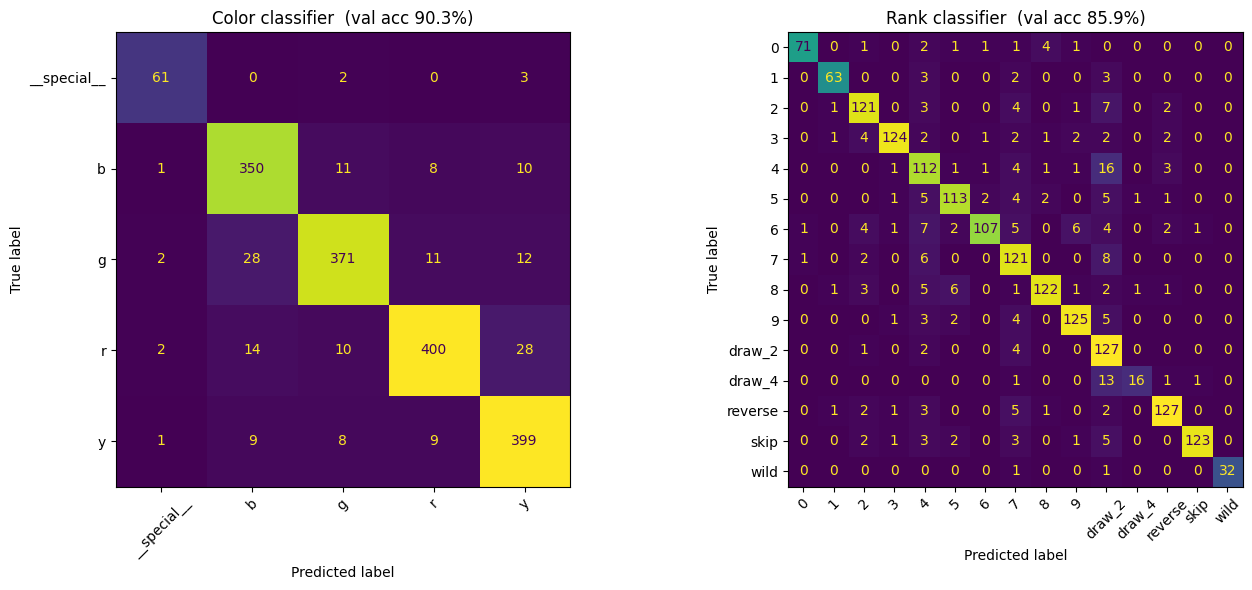


── Full-label classification report ──────────────────────────────────
              precision    recall  f1-score   support

         b_1       1.00      0.67      0.80         3
         b_2       0.88      0.94      0.91        31
         b_3       0.93      0.87      0.90        31
         b_4       0.68      0.72      0.70        36
         b_5       0.89      0.84      0.86        37
         b_6       0.87      0.82      0.84        33
         b_7       0.74      0.78      0.76        32
         b_8       0.97      0.89      0.93        38
         b_9       0.90      0.85      0.88        33
    b_draw_2       0.65      0.88      0.75        32
   b_reverse       0.88      0.92      0.90        39
      b_skip       1.00      0.86      0.92        35
      draw_4       0.89      0.50      0.64        32
         g_0       1.00      0.39      0.56        41
         g_1       0.60      1.00      0.75         3
         g_2       0.85      0.85      0.85        34
         

In [6]:
# ── Confusion matrices ────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

ConfusionMatrixDisplay.from_predictions(
    y_col_va, pred_col,
    display_labels=color_le.classes_,
    ax=axes[0], xticks_rotation=45, colorbar=False,
)
axes[0].set_title(f"Color classifier  (val acc {col_va_acc * 100:.1f}%)")

ConfusionMatrixDisplay.from_predictions(
    y_rnk_va, pred_rnk,
    display_labels=rank_le.classes_,
    ax=axes[1], xticks_rotation=45, colorbar=False,
)
axes[1].set_title(f"Rank classifier  (val acc {rnk_va_acc * 100:.1f}%)")

plt.tight_layout()
plt.show()

print("\n── Full-label classification report ──────────────────────────────────")
print(classification_report(true_full, pred_full, zero_division=0))


Wrong predictions: 298 / 1750


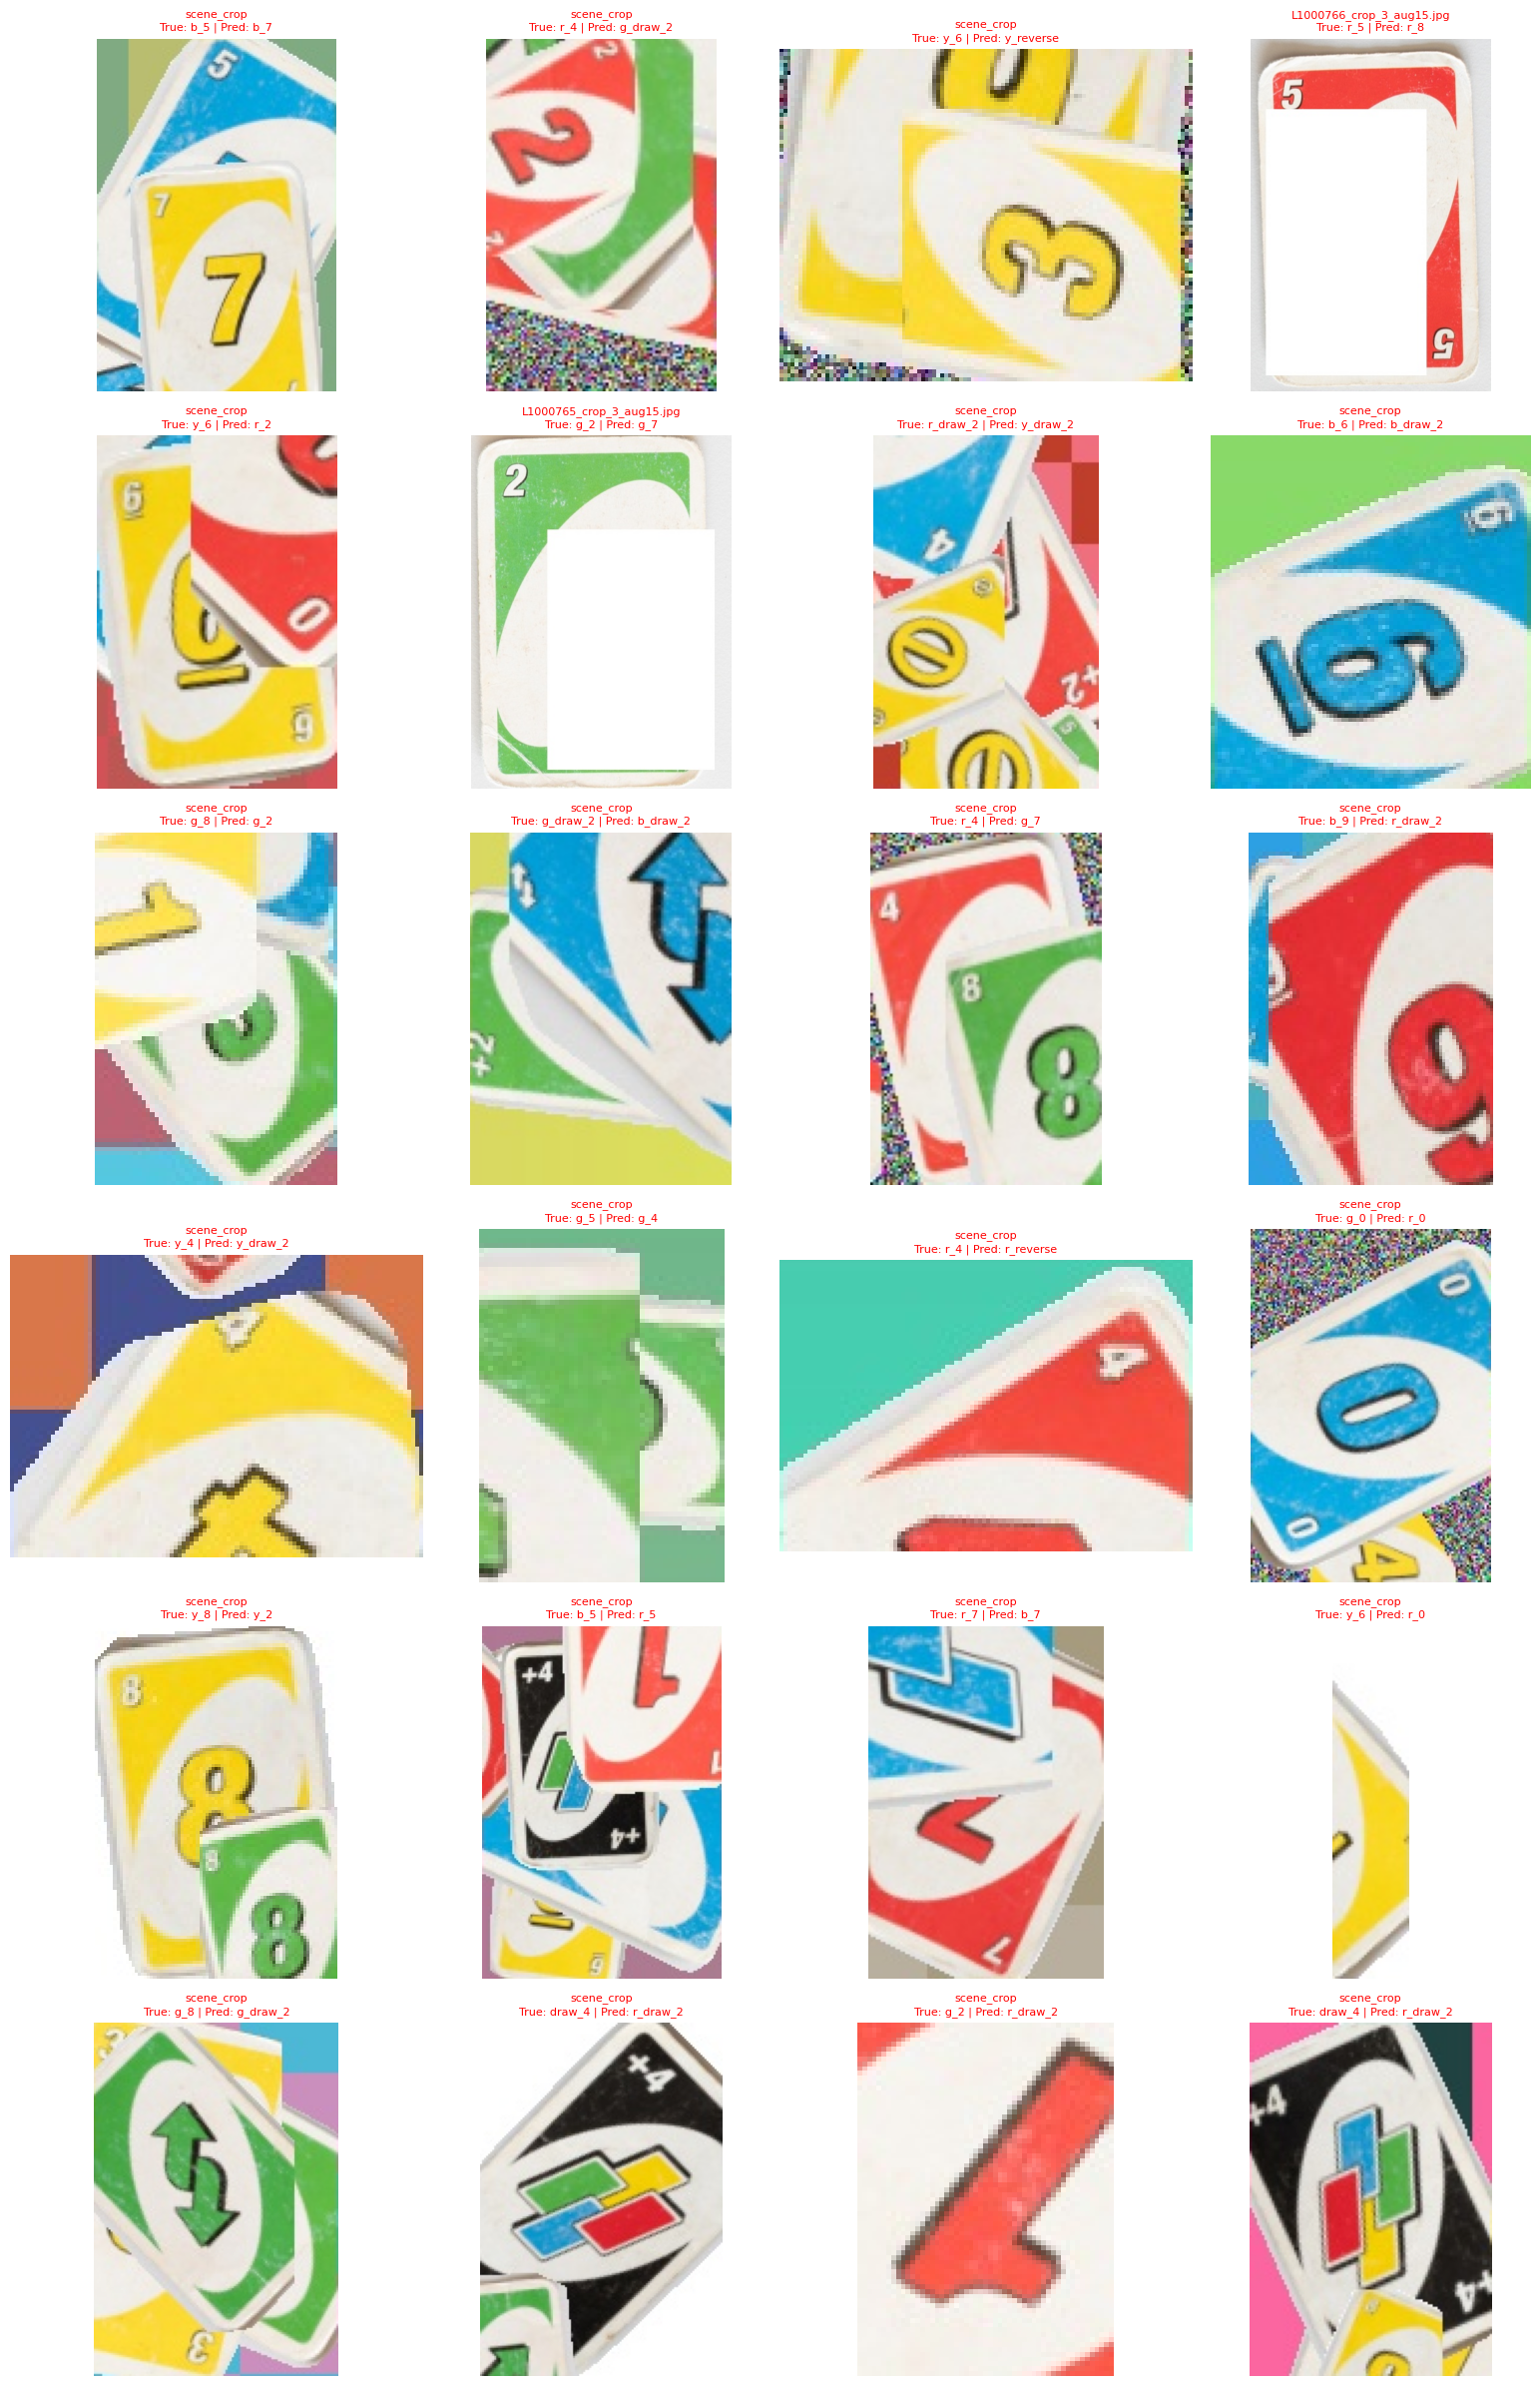

In [8]:
# ── Misclassification viewer ──────────────────────────────────────────────────
wrong_preds = [
    (path, true_lbl, pred_lbl)
    for path, true_lbl, pred_lbl in zip(paths_val, true_full, pred_full)
    if pred_lbl != true_lbl
]

print(f"Wrong predictions: {len(wrong_preds)} / {len(paths_val)}")

if len(wrong_preds) == 0:
    print("No wrong predictions on the validation split.")
else:
    max_show = min(24, len(wrong_preds))
    cols = 4
    rows = math.ceil(max_show / cols)

    fig, axes = plt.subplots(rows, cols, figsize=(4 * cols, 4 * rows))
    axes = np.array(axes).reshape(-1)

    for i in range(max_show):
        path, true_lbl, pred_lbl = wrong_preds[i]
        if isinstance(path, str):
            img = Image.open(path).convert("RGB")
            title_name = os.path.basename(path)
        else:
            img = Image.fromarray(cv2.cvtColor(path, cv2.COLOR_BGR2RGB))
            title_name = "scene_crop"
        axes[i].imshow(img)
        axes[i].set_title(
            f"{title_name}\nTrue: {true_lbl} | Pred: {pred_lbl}",
            color="red", fontsize=8,
        )
        axes[i].axis("off")

    for j in range(max_show, len(axes)):
        axes[j].axis("off")

    plt.tight_layout()
    plt.show()
